Running simulations with N = 10,000 nodes...
  Simulating Scale-Free...
    M(0)=1.0199e-06, M(end)=0.9987
  Simulating Power Law...
    M(0)=1.0142e-06, M(end)=0.9983
  Simulating Log-Normal...
    M(0)=1.0158e-06, M(end)=1.0008
  Simulating Weibull...
    M(0)=1.0140e-06, M(end)=0.9999
  Simulating Exponential...
    M(0)=1.0127e-06, M(end)=0.9993
  Simulating Erdős-Rényi...
    M(0)=1.0154e-06, M(end)=1.0005

Plots saved.


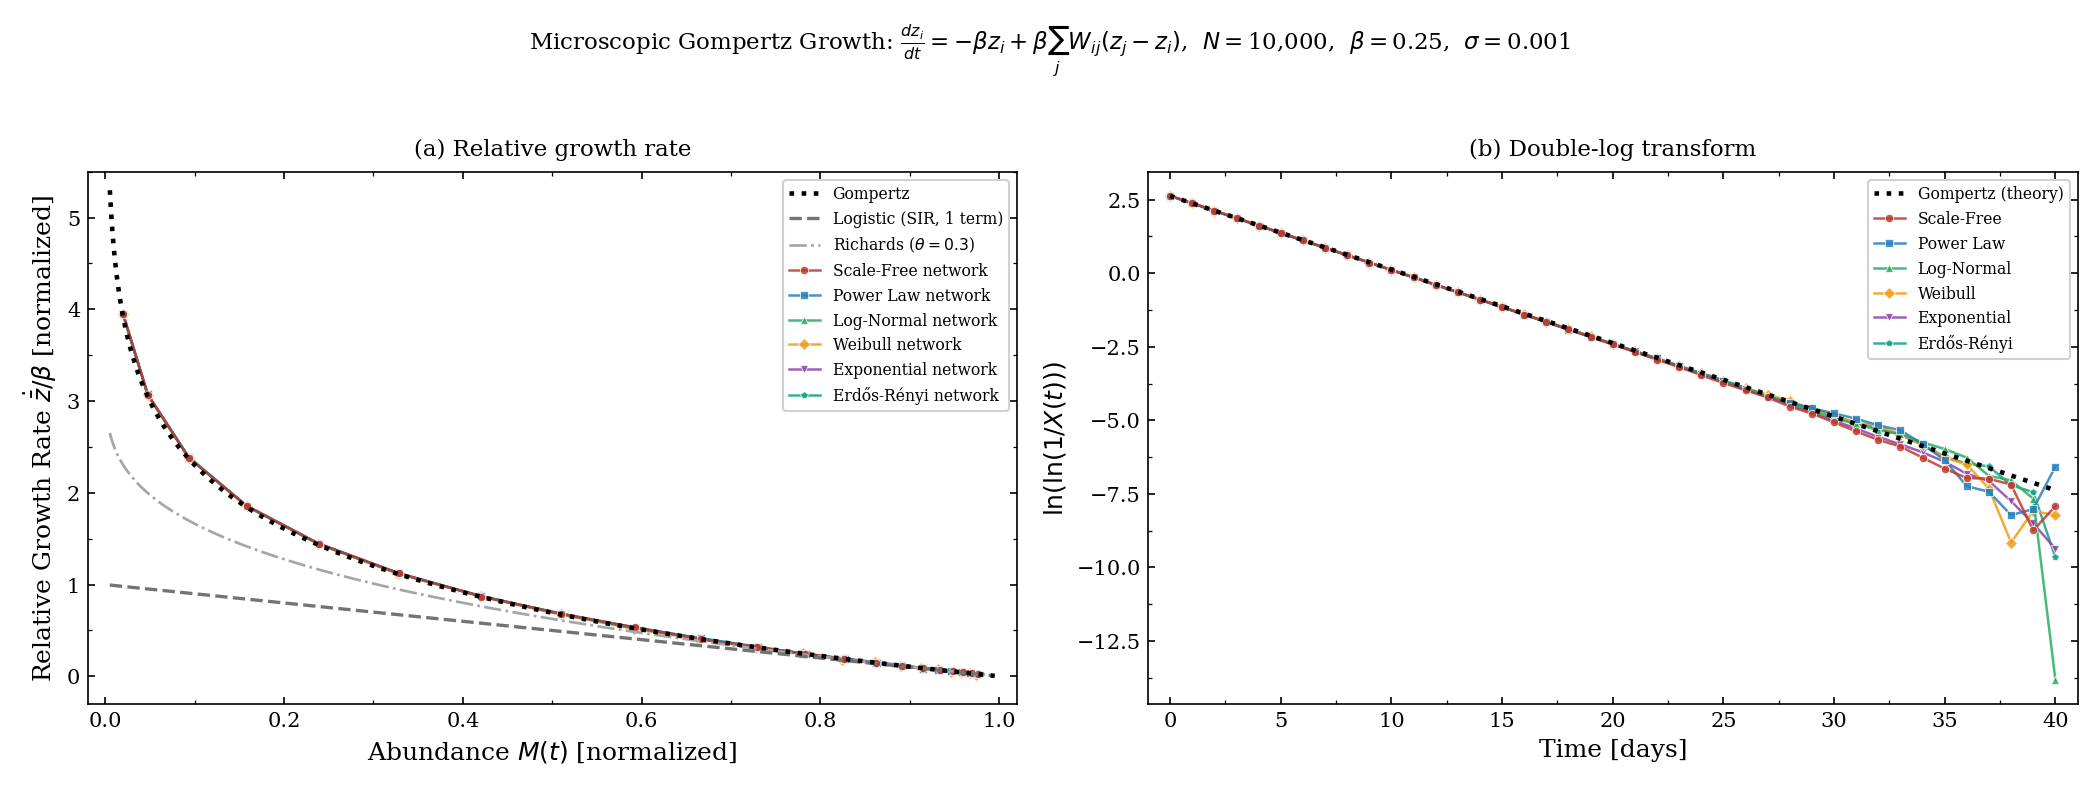

In [2]:
"""
Microscopic Gompertz Growth on Networks
========================================
Simulates N coupled nodes undergoing Gompertz growth in the log-domain
with diffusive coupling on various network topologies.

Model (in log-domain, z_i = ln x_i):

    dz_i/dt = -β z_i + β Σ_j W_ij (z_j - z_i) + √σ dW_i

where W is a row-normalized (doubly stochastic on regular graphs) weight
matrix derived from the adjacency structure. The macroscopic observable
is the geometric mean M(t) = exp(mean(z_i)).

We compare the relative growth rate γ(M) = d/dt ln(M) / (-β) against
the theoretical Gompertz curve γ = ln(1/M), analogous to Fig 2 in the paper.
"""
"""
Microscopic Gompertz Growth on Networks
========================================
Simulates N coupled nodes undergoing Gompertz growth in the log-domain
with diffusive coupling on various network topologies.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import warnings
warnings.filterwarnings("ignore")

# ─── Parameters ───────────────────────────────────────────────────────────────

N = 10_000
BETA = 0.25
SIGMA = 0.001
DT = 0.05
T_MAX = 40.0
SEED = 42

rng = np.random.default_rng(SEED)

# ─── Network Degree Generators ────────────────────────────────────────────────

def degree_scale_free(N, rng):
    u = rng.random(N)
    return np.maximum(2, np.floor(2 * (1 - u) ** (-0.5)).astype(int))

def degree_power_law(N, rng):
    u = rng.random(N)
    return np.maximum(2, np.floor(2 * (1 - u) ** (-1/1.2)).astype(int))

def degree_log_normal(N, rng):
    z = rng.standard_normal(N)
    return np.maximum(2, np.round(np.exp(1.5 + 0.8 * z)).astype(int))

def degree_weibull(N, rng):
    u = rng.random(N)
    return np.maximum(2, np.round(5 * (-np.log(1 - u)) ** (1/1.5)).astype(int))

def degree_exponential(N, rng):
    return np.maximum(2, np.round(rng.exponential(4, N)).astype(int))

def degree_erdos_renyi(N, rng):
    return np.maximum(2, rng.poisson(6, N))

NETWORKS = {
    "Scale-Free":    degree_scale_free,
    "Power Law":     degree_power_law,
    "Log-Normal":    degree_log_normal,
    "Weibull":       degree_weibull,
    "Exponential":   degree_exponential,
    r"Erdős-Rényi":  degree_erdos_renyi,
}

# ─── Simulation Core ──────────────────────────────────────────────────────────

def build_weights(degrees):
    k = degrees.astype(np.float64)
    return k / k.sum()

def simulate(degree_fn, rng):
    degrees = degree_fn(N, rng)
    weights = build_weights(degrees)
    z = rng.normal(loc=-13.8, scale=0.3, size=N)
    steps = int(T_MAX / DT)
    M_traj = np.zeros(steps + 1)
    M_traj[0] = np.exp(np.mean(z))
    noise_scale = np.sqrt(SIGMA * DT)
    for t_idx in range(steps):
        z_bar = np.sum(weights * z)
        coupling = z_bar - z
        dz = (-BETA * z + BETA * coupling) * DT + noise_scale * rng.standard_normal(N)
        z += dz
        M_traj[t_idx + 1] = np.exp(np.mean(z))
    return M_traj

# ─── Theoretical Curves ──────────────────────────────────────────────────────

def gompertz_gamma(M):
    return -np.log(np.clip(M, 1e-15, None))

def logistic_gamma(M):
    return 1 - M

def richards_gamma(M, theta):
    return (1 - M**theta) / theta

# ─── Run All Simulations ─────────────────────────────────────────────────────

print("Running simulations with N = {:,} nodes...".format(N))
results = {}
for name, fn in NETWORKS.items():
    print(f"  Simulating {name}...")
    M = simulate(fn, rng)
    results[name] = M
    print(f"    M(0)={M[0]:.4e}, M(end)={M[-1]:.4f}")

# ─── Plotting ─────────────────────────────────────────────────────────────────

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.linewidth": 0.8,
    "axes.labelsize": 12,
    "legend.fontsize": 8.5,
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "legend.edgecolor": "0.8",
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.15,
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Left panel: Relative growth rate vs abundance ──

M_th = np.linspace(0.005, 0.995, 500)

ax1.plot(M_th, gompertz_gamma(M_th), color="black", lw=2.2, ls=":",
         label="Gompertz", zorder=10)
ax1.plot(M_th, logistic_gamma(M_th), color="0.45", lw=1.6, ls="--",
         label="Logistic (SIR, 1 term)", zorder=9)
ax1.plot(M_th, richards_gamma(M_th, 0.3), color="0.65", lw=1.3, ls="-.",
         label=r"Richards ($\theta=0.3$)", zorder=8)

colors = ["#c0392b", "#2980b9", "#27ae60", "#f39c12", "#8e44ad", "#16a085"]
markers = ["o", "s", "^", "D", "v", "p"]

for idx, (name, M) in enumerate(results.items()):
    M_norm = (M - M.min()) / (M.max() - M.min())
    M_norm = np.clip(M_norm, 1e-6, 1 - 1e-6)
    dM = np.gradient(M_norm, DT)
    gamma = dM / M_norm
    gamma_norm = gamma / BETA
    step = max(1, len(M_norm) // 40)
    M_sub = M_norm[::step]
    g_sub = gamma_norm[::step]
    mask = (M_sub > 0.01) & (M_sub < 0.98) & (g_sub > -0.5) & (g_sub < 8)
    ax1.plot(M_sub[mask], g_sub[mask],
             color=colors[idx], marker=markers[idx], markersize=4,
             lw=1.2, alpha=0.85, markeredgewidth=0.4, markeredgecolor="white",
             label=f"{name} network", zorder=7 - idx)

ax1.set_xlabel("Abundance $M(t)$ [normalized]")
ax1.set_ylabel(r"Relative Growth Rate $\dot{\bar{z}} / \beta$ [normalized]")
ax1.set_xlim(-0.02, 1.02)
ax1.set_ylim(-0.3, 5.5)
ax1.xaxis.set_minor_locator(AutoMinorLocator(2))
ax1.yaxis.set_minor_locator(AutoMinorLocator(2))
ax1.tick_params(which="both", direction="in", top=True, right=True)
ax1.legend(loc="upper right", ncol=1, fontsize=7.5)
ax1.set_title("(a) Relative growth rate", fontsize=11, pad=8)

# ── Right panel: Double-log transform vs time ──
# g(Y) = ln(ln(Y_inf / Y(t))), straight negative line = Gompertz

t_arr = np.linspace(0, T_MAX, int(T_MAX / DT) + 1)

# Theoretical Gompertz double-log: ln(ln(Y_inf/Y)) = -β t + const
# Use Y = Y_inf * (Y0/Y_inf)^exp(-β t), so ln(Y_inf/Y) = -ln(Y0/Y_inf)*exp(-β t)
# and ln(ln(Y_inf/Y)) = ln(-ln(Y0/Y_inf)) - β t
t_theory = np.linspace(0, T_MAX, 300)
# Use representative Y0/Y_inf from simulations
Y0_ratio = list(results.values())[0][0] / list(results.values())[0][-1]
const = np.log(-np.log(Y0_ratio))
ax2.plot(t_theory, -BETA * t_theory + const, color="black", lw=2.2, ls=":",
         label="Gompertz (theory)", zorder=10)

for idx, (name, M) in enumerate(results.items()):
    M_norm = (M - M.min()) / (M.max() - M.min())
    M_norm = np.clip(M_norm, 1e-6, 1 - 1e-6)
    # Double-log: ln(ln(1/M)) = ln(-ln(M))
    with np.errstate(invalid="ignore", divide="ignore"):
        dlog = np.log(-np.log(M_norm))
    valid = np.isfinite(dlog)
    t_valid = t_arr[valid]
    dlog_valid = dlog[valid]
    step = max(1, len(t_valid) // 40)
    ax2.plot(t_valid[::step], dlog_valid[::step],
             color=colors[idx], marker=markers[idx], markersize=4,
             lw=1.2, alpha=0.85, markeredgewidth=0.4, markeredgecolor="white",
             label=f"{name}", zorder=7 - idx)

ax2.set_xlabel("Time [days]")
ax2.set_ylabel(r"$\ln(\ln(1/X(t)))$")
ax2.set_xlim(-1, T_MAX + 1)
ax2.xaxis.set_minor_locator(AutoMinorLocator(2))
ax2.yaxis.set_minor_locator(AutoMinorLocator(2))
ax2.tick_params(which="both", direction="in", top=True, right=True)
ax2.legend(loc="upper right", ncol=1, fontsize=7.5)
ax2.set_title("(b) Double-log transform", fontsize=11, pad=8)

fig.suptitle(
    r"Microscopic Gompertz Growth: $\frac{dz_i}{dt} = -\beta z_i + \beta \sum_j W_{ij}(z_j - z_i)$"
    f",  $N = ${N:,},  "
    r"$\beta=$" + f"{BETA},  " + r"$\sigma=$" + f"{SIGMA}",
    fontsize=11, y=1.02
)

plt.tight_layout()
plt.savefig("../figures/gompertz_networks.png")
plt.savefig("../figures/gompertz_networks.pdf")
print("\nPlots saved.")

In [13]:
z = rng.normal(loc=-13.6, scale=3, size=10000)

In [14]:
z

array([-11.07081381, -13.59432113,  -9.83285549, ..., -11.13126388,
        -5.33906336,  -6.43724204], shape=(10000,))